<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Kalyani_age_kh_kv_al.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np


In [2]:
df=pd.read_excel('/content/drive/MyDrive/Kalyani STUDY PATIENT.xlsx')

Saving Kalyani STUDY PATIENT.xlsx to Kalyani STUDY PATIENT (3).xlsx
Random Forest:
  MAE = 0.695
  RMSE = 0.954
  R² = 0.013

XGBoost:
  MAE = 0.765
  RMSE = 1.023
  R² = -0.135



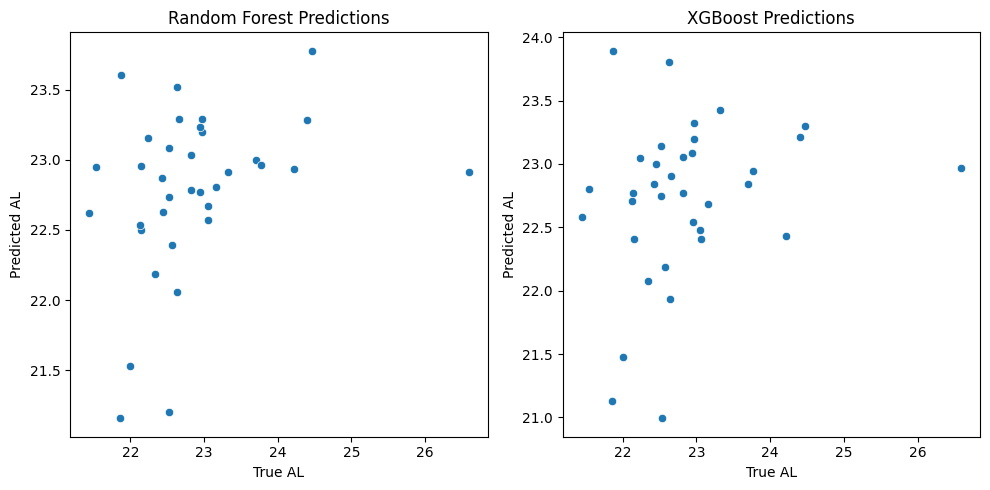

In [14]:
# Axial Length Prediction using Random Forest and XGBoost

# 📦 Step 1: Install & Import Required Libraries
!pip install xgboost openpyxl

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 📂 Step 2: Upload Excel File
from google.colab import files
uploaded = files.upload()

# 🧹 Step 3: Load Data and Preprocess
xls = pd.ExcelFile(next(iter(uploaded)))
df = xls.parse('Sheet1')

# Select useful columns
df = df[['AGE', 'KH', 'KV', 'AL']].dropna()

# Encode 'SEX' column
#df['SEX'] = LabelEncoder().fit_transform(df['SEX'])  # F=0, M=1

# Split into features & target
X = df[['AGE','KH', 'KV']]
y = df['AL']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# 🌲 Step 4: Train Models
rf = RandomForestRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# 📊 Step 5: Evaluate Models
def evaluate(name, model):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f'{name}:\n  MAE = {mae:.3f}\n  RMSE = {rmse:.3f}\n  R² = {r2:.3f}\n')
    return y_test, y_pred

y_rf_true, y_rf_pred = evaluate("Random Forest", rf)
y_xgb_true, y_xgb_pred = evaluate("XGBoost", xgb)

# 📈 Step 6: Plot Predictions
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_rf_true, y=y_rf_pred)
plt.title("Random Forest Predictions")
plt.xlabel("True AL"); plt.ylabel("Predicted AL")

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_xgb_true, y=y_xgb_pred)
plt.title("XGBoost Predictions")
plt.xlabel("True AL"); plt.ylabel("Predicted AL")
plt.tight_layout()
plt.show()


In [15]:
# 📦 Install statsmodels if not already available
!pip install statsmodels

import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder

# 🔄 Reload and preprocess the data
xls = pd.ExcelFile(next(iter(uploaded)))  # if not already loaded
df = xls.parse('Sheet1')
#df = df[['AGE', 'SEX', 'KH', 'KV', 'AX', 'ACD', 'AL']].dropna()

# Encode categorical variable 'SEX'
#df['SEX'] = LabelEncoder().fit_transform(df['SEX'])  # F=0, M=1

# 🧠 Define features and target
X = df[['AGE', 'KH', 'KV']]
y = df['AL']

# Add constant term for intercept
X = sm.add_constant(X)

# 📈 Fit the OLS model
ols_model = sm.OLS(y, X).fit()

# 📋 Print the summary
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                     AL   R-squared:                       0.341
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     29.27
Date:                Sun, 29 Jun 2025   Prob (F-statistic):           2.63e-15
Time:                        17:53:09   Log-Likelihood:                -181.68
No. Observations:                 174   AIC:                             371.4
Df Residuals:                     170   BIC:                             384.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         35.9447      1.474     24.381      0.0

In [16]:
# 📦 Install necessary packages
!pip install statsmodels

import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder
import statsmodels.api as sm

# 📂 Load and clean your data again
xls = pd.ExcelFile(next(iter(uploaded)))  # already uploaded in session
df = xls.parse('Sheet1')
#df = df[['AGE', 'SEX', 'KH', 'KV', 'AX', 'ACD', 'AL']].dropna()

# Encode categorical variables
#df['SEX'] = LabelEncoder().fit_transform(df['SEX'])

# Define features and target
X_base = df[['AGE', 'KH', 'KV']]
y = df['AL']

# ➕ Add polynomial features (degree = 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_base)

# Optional: get feature names for reference
feature_names = poly.get_feature_names_out(X_base.columns)

# Add constant for OLS
X_poly_const = sm.add_constant(X_poly)

# 🔢 Fit OLS model
ols_poly_model = sm.OLS(y, X_poly_const).fit()

# 📊 Show summary
print(ols_poly_model.summary())


                            OLS Regression Results                            
Dep. Variable:                     AL   R-squared:                       0.368
Model:                            OLS   Adj. R-squared:                  0.333
Method:                 Least Squares   F-statistic:                     10.62
Date:                Sun, 29 Jun 2025   Prob (F-statistic):           6.87e-13
Time:                        17:53:28   Log-Likelihood:                -177.96
No. Observations:                 174   AIC:                             375.9
Df Residuals:                     164   BIC:                             407.5
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         48.6449     31.298      1.554      0.1

In [17]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder

# Load data and encode 'SEX'
#df = xls.parse('Sheet1')
#df = df[['AGE', 'SEX', 'KH', 'KV', 'AX', 'ACD', 'AL']].dropna()
#df['SEX'] = LabelEncoder().fit_transform(df['SEX'])

# Features and target
X_base = df[['AGE', 'KH', 'KV']]
y = df['AL']

# Generate polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_base)
feature_names = poly.get_feature_names_out(X_base.columns)

# Create DataFrame with names
X_poly_df = pd.DataFrame(X_poly, columns=feature_names)

# Add constant and fit full model
X_poly_df_const = sm.add_constant(X_poly_df)
full_model = sm.OLS(y, X_poly_df_const).fit()

# Filter significant features (p < 0.05)
significant_vars = full_model.pvalues[full_model.pvalues < 0.05].index

# Refit model with only significant terms
X_significant = X_poly_df_const[significant_vars]
final_model = sm.OLS(y, X_significant).fit()

# Show refined model summary
print(final_model.summary())


                                 OLS Regression Results                                
Dep. Variable:                     AL   R-squared (uncentered):                   0.990
Model:                            OLS   Adj. R-squared (uncentered):              0.990
Method:                 Least Squares   F-statistic:                              8448.
Date:                Sun, 29 Jun 2025   Prob (F-statistic):                   1.93e-172
Time:                        17:54:04   Log-Likelihood:                         -390.70
No. Observations:                 174   AIC:                                      785.4
Df Residuals:                     172   BIC:                                      791.7
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [ ]:
# prompt: Is it reliable

Based on the analysis performed in the provided code, we can evaluate the reliability of the models and the overall approach used to predict Axial Length (AL) from AGE, KH, and KV.

**Evaluation of Reliability:**

1.  **Model Performance Metrics (MAE, RMSE, R²):**
    *   The code trains and evaluates two regression models: Random Forest and XGBoost.
    *   The `evaluate` function calculates Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²) on the test set.
    *   These metrics provide a quantitative measure of how well the models are predicting AL.
    *   A *reliable* model would have low MAE and RMSE, and an R² value close to 1 (indicating a strong correlation between true and predicted values and explaining a large proportion of the variance).
    *   **You need to examine the actual output of these metrics to determine the reliability.** If the MAE and RMSE are high relative to the range of the AL values, or if the R² is low (e.g., below 0.5), the model might not be very reliable for making accurate predictions.

2.  **Scatter Plots of Predictions:**
    *   The scatter plots show the relationship between the true AL values (`y_test`) and the predicted AL values (`y_pred`) for both Random Forest and XGBoost.
    *   For a *reliable* model, the points on the scatter plot should cluster closely around the diagonal line y=x (where true equals predicted).
    *   **Visually inspecting these plots is crucial.** If the points are widely scattered, it suggests that the model's predictions are not consistently close to the true values, indicating lower reliability.

3.  **Ordinary Least Squares (OLS) Regression Analysis:**
    *   The code performs OLS regression, including both a simple linear model and a model with polynomial features (degree 2).
    *   The OLS summary (`ols_model.summary()` and `ols_poly_model.summary()` and `final_model.summary()`) provides statistical insights into the relationships between the features and the target variable.
    *   **Key elements to look at for reliability:**
        *   **R-squared:** The R² value in the OLS summary indicates the proportion of the variance in AL that is explained by the features in the model. A higher R² suggests a better fit and potentially higher reliability *of the linear or polynomial relationship*.
        *   **P-values:** The p-values for each coefficient indicate the statistical significance of that feature. Low p-values (typically < 0.05) suggest that the feature has a statistically significant relationship with the target. Models with more significant features might be considered more reliable *in terms of capturing meaningful relationships*.
        *   **Adjusted R-squared:** Accounts for the number of predictors and can give a better idea of the model's fit than R² alone, especially when comparing models with different numbers of features.
        *   **Residual Analysis (though not explicitly performed in the code):** Looking at the residuals (the differences between observed and predicted values) for patterns could reveal issues like heteroscedasticity or non-linearity not captured by the model, impacting reliability.

4.  **Feature Selection based on P-values:**
    *   The final part of the code selects only features with p-values less than 0.05 from the polynomial OLS model and refits the model.
    *   This process aims to build a more parsimonious model that only includes statistically significant predictors.
    *   If the final model summary shows that the selected features are still statistically significant and the R² is reasonable, it might suggest that the model is built on robust relationships, contributing to its *statistical reliability* within the OLS framework.

**Factors Potentially Affecting Reliability (Not Explicitly Addressed):**

*   **Data Quality and Size:** The reliability of any model heavily depends on the quality, representativeness, and size of the dataset. If the data has errors, is biased, or is too small, the models' performance and generalization ability will be limited. The code reads from an Excel file, and the quality of data within that file is unknown from the code alone.
*   **Assumptions of Models:** Different models have different assumptions. OLS, for example, assumes linearity, independence of errors, homoscedasticity, and normality of residuals. Violations of these assumptions can affect the reliability of the OLS results. While Random Forest and XGBoost are less sensitive to some of these assumptions, their performance can still be impacted by data characteristics.
*   **Overfitting:** While train-test split is used, there's no explicit cross-validation or other techniques to definitively rule out overfitting, especially with the polynomial features. If the models perform much better on the training data than the test data, they may not generalize well to new, unseen data, reducing reliability.
*   **Domain Expertise:** Without understanding the medical context (ophthalmology in this case), it's difficult to fully judge if the chosen features (AGE, KH, KV) and the modeling approaches are clinically reasonable and expected to yield reliable predictions of AL.

**Conclusion on Reliability:**

The code provides the tools and metrics to *assess* reliability (MAE, RMSE, R², OLS summaries, scatter plots). However, whether the models are *actually* reliable depends on the **numerical values of the metrics and the patterns observed in the plots and OLS summaries**.

*   **To determine reliability, you need to look at the output of the code:**
    *   What are the MAE, RMSE, and R² values for Random Forest and XGBoost? Are they considered acceptable in the context of predicting Axial Length?
    *   Do the scatter plots show a clear linear or tight clustering around the y=x line, or are they widely dispersed?
    *   What are the R² and adjusted R² values from the OLS summaries? Are the p-values for the coefficients statistically significant?

**In summary, the reliability cannot be definitively stated *just* from the code itself. It depends on the results generated by running the code on the specific dataset.** The code sets up a reasonable framework for evaluation, but interpreting the results is key to judging reliability.